In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet101
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [ ]:
BATCH_SIZE = 16

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
base_model = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

171446536/171446536 [==============================] - 22s 0us/step


In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101 (Functional)      (None, 7, 7, 2048)        42658176  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 43,185,290
Trainable params: 527,114
Non-trainable params: 42,658,176
______________________________________

In [8]:
start_time = time.time()

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/10
3125/3125 [==============================] - 209s 63ms/step - loss: 2.2734 - accuracy: 0.1450 - val_loss: 2.2080 - val_accuracy: 0.2110
Epoch 2/10
3125/3125 [==============================] - 201s 64ms/step - loss: 2.1763 - accuracy: 0.1932 - val_loss: 2.1119 - val_accuracy: 0.2606
Epoch 3/10
3125/3125 [==============================] - 197s 63ms/step - loss: 2.0973 - accuracy: 0.2247 - val_loss: 2.0457 - val_accuracy: 0.2563
Epoch 4/10
3125/3125 [==============================] - 198s 63ms/step - loss: 2.0468 - accuracy: 0.2421 - val_loss: 1.9998 - val_accuracy: 0.2818
Epoch 5/10
3125/3125 [==============================] - 194s 62ms/step - loss: 2.0137 - accuracy: 0.2546 - val_loss: 1.9650 - val_accuracy: 0.2965
Epoch 6/10
3125/3125 [==============================] - 205s 65ms/step - loss: 1.9945 - accuracy: 0.2583 - val_loss: 1.9465 - val_accuracy: 0.2973
Epoch 7/10
3125/3125 [==============================] - 206s 66ms/step - loss: 1.9766 - accuracy: 0.2673 - val_loss: 1

In [9]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 31.70%
Test Loss: 1.8967


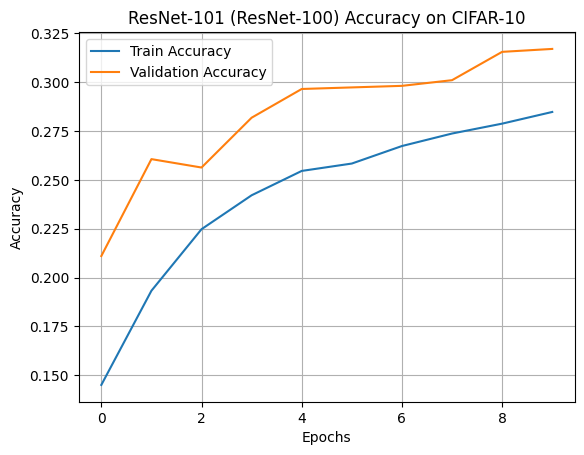

In [10]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet-101 (ResNet-100) Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

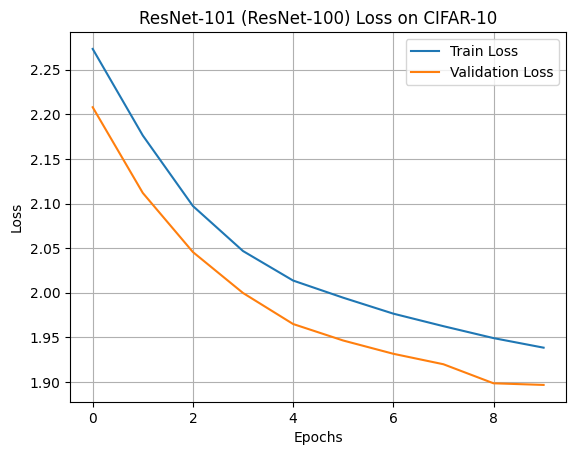

In [11]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-101 (ResNet-100) Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 43,185,290
